In [113]:
import datetime
import os
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML
from collections import defaultdict
import yfinance as yf

#Define where the corresponding functions are:
filename_func1 = "Indicators.py"
filename_func3 = "Plot2.py"
    
if os.path.isfile("Updater.py")==True:
    %run Updater.py
    
%run Functions/$filename_func1
%run Functions/$filename_func3

if os.path.isfile("Stock_information.py")==True:
    %run Stock_information.py
else:
    account = ["PTX.DE"]
    c = [{}]
    b = ["ETH-EUR"],[1],[1000]

In [3]:
d_ib, d_h1y, d_cal_EQI, d_qis_EQI, d_top_ETF = get_my_stock_data(account,"2y")

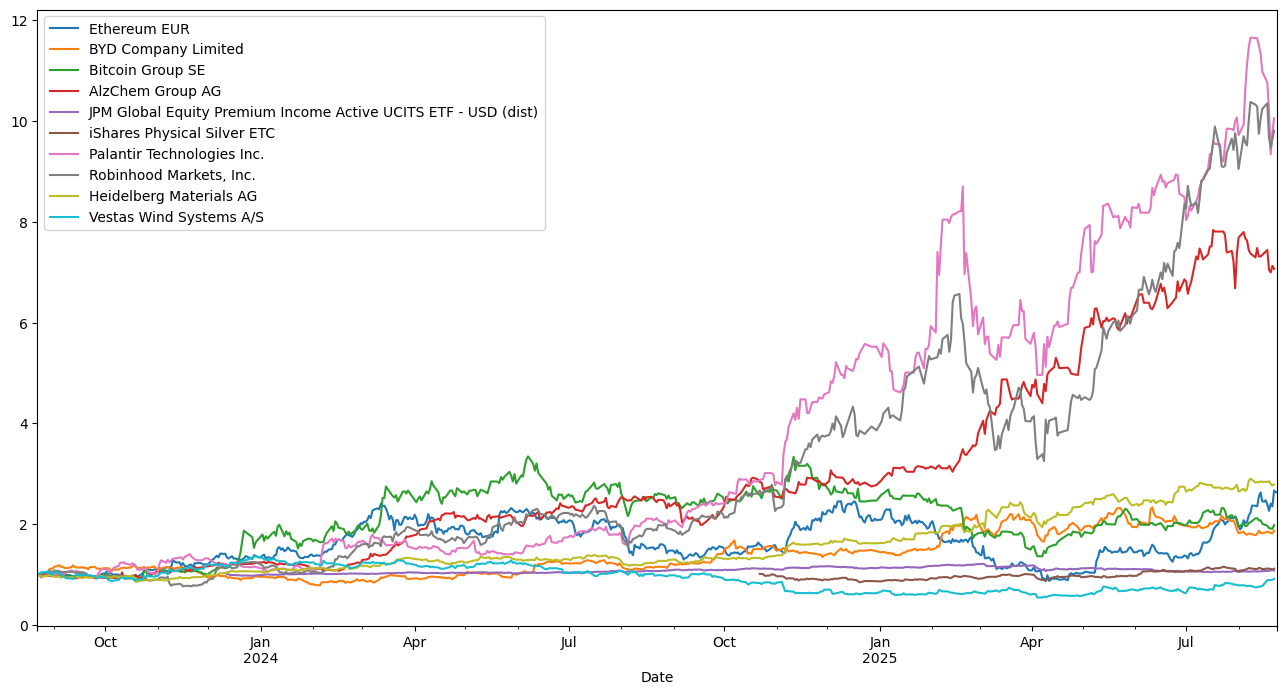

In [ ]:
# Cumulative return for stocks from "account" over the last 2 years (10 = 10x the original invest)
plot_my_stock_comparision(account, d_h1y, d_ib)

In [5]:
df_equities, df_etfs, df_other = get_my_stock_variation2(account,d_h1y,d_ib, d_cal_EQI, d_qis_EQI, d_top_ETF)
        
plot_equity_table(df_equities, df_etfs, df_other, width="1200px", height = "800px")

,Ticker,Short Name,Type,Currency,Mean [%],3xStd [%],Last RSI,Sector,Industry,Book Value,KGV,f_KGV,Last Earnings Date,Next Earnings Date,Total Revenue,Rev % Change,Gross Profit,Profit % Change,EBIT,EBIT % Change
0,BY6.F,BYD Co. Ltd. R,EQUITY,EUR/CNY,0.16,8.18,52.96,Consumer Cyclical,Auto Manufacturers,24.806,20.50,NaN,31.03.2025,29.08.2025,170360 Mio,-38.02%,34185 Mio,-26.89%,11792 Mio,-37.22%
1,ADE.DE,Bitcoin Group SE I,EQUITY,EUR/EUR,0.21,12.08,46.93,Financial Services,Asset Management,55.639,113.89,61.19,None,,None,None,None,None,None,None
2,ACT.DE,Alzchem Group AG I,EQUITY,EUR/EUR,0.42,8.12,27.44,Basic Materials,Specialty Chemicals,21.505,25.04,76.47,30.06.2025,30.07.2025,142 Mio,-1.24%,101 Mio,10.18%,23 Mio,8.21%
3,PTX.DE,Palantir Technologies Inc. R,EQUITY,EUR/USD,0.54,12.64,51.31,Technology,Software - Infrastructure,2.500,532.77,NaN,30.06.2025,03.11.2025,1003 Mio,13.56%,810 Mio,14.05%,269 Mio,52.98%
4,7KY.F,Robinhood Markets Inc. R,EQUITY,EUR/USD,0.53,12.25,51.55,Financial Services,Capital Markets,9.088,54.83,NaN,30.06.2025,29.10.2025,989 Mio,6.69%,848 Mio,6.94%,439 Mio,18.01%
5,HEI.DE,Heidelberg Materials AG I,EQUITY,EUR/EUR,0.22,5.78,57.92,Basic Materials,Building Materials,96.712,19.57,16.32,None,31.07.2025,None,None,None,None,None,None
6,VWSB.DE,Vestas Wind Systems A/S N,EQUITY,EUR/EUR,0.02,8.64,78.40,Industrials,Specialty Industrial Machinery,2.913,24.22,19.17,30.06.2025,05.11.2025,3745 Mio,7.99%,417 Mio,16.16%,57 Mio,307.14%


,Ticker,Short Name,Type,Currency,Mean [%],3xStd [%],Last RSI,Top Holdings
0,JGPI.DE,JPM EII-Gl.Eq.Pr.In.Ac.UCI.ETFR,ETF,EUR/,0.02,1.97,66.68,Southern Co (1.88%)Microsoft Corp (1.77%)Deutsche Telekom AG (1.67%)Johnson & Johnson (1.39%)Roper Technologies Inc (1.32%)Berkshire Hathaway Inc Class B (1.32%)Motorola Solutions Inc (1.31%)McDonald's Corp (1.2%)PepsiCo Inc (1.18%)NTT Inc (1.14%)


,Ticker,Short Name,Type,Currency,Mean [%],3xStd [%],Last RSI
0,ETH-EUR,Ethereum EUR,CRYPTOCURRENCY,EUR/,0.19,10.66,60.44
1,PPFD.SG,iShares Physical Silver ETC,MUTUALFUND,EUR/,0.06,4.48,63.31


In [6]:
multi_plot3(dfi = d_ib,dfh = d_h1y, title="Charts", account = account)

In [7]:
which=1
tick=account[which] 
dfv=yf.Ticker(tick).income_stmt/1000000
quarterly_income_statement = yf.Ticker(tick).quarterly_income_stmt/1000000
        
income_statement_overview(which, d_ib,dfv, quarterly_income_statement)

,2025-03-31,2024-12-31,2024-09-30,2024-06-30,2024-03-31
Total Revenue,170360.448,274851.143,201124.599,176182.316,124944.397
Gross Profit,34185.063,46758.090,44031.018,32925.721,25870.115
EBITDA,11792.343,18783.411,14646.849,12046.384,6297.814
EBITDA percentage,6.920,6.830,7.280,6.840,5.040


,NaT,2024-12-31,2023-12-31,2022-12-31,2021-12-31,2020-12-31
Total Revenue,822518.506,777102.455,602315.354,424060.635,216142.395,NaN
Gross Profit,157899.892,151055.839,111916.409,72244.955,28144.706,NaN
EBIT,57268.987,51774.458,39096.242,22396.079,6425.645,NaN
EBITDA,57268.987,116853.507,82378.814,42684.498,20506.744,NaN
EBITDA percentage,6.960,15.040,13.680,10.070,9.490,NaN


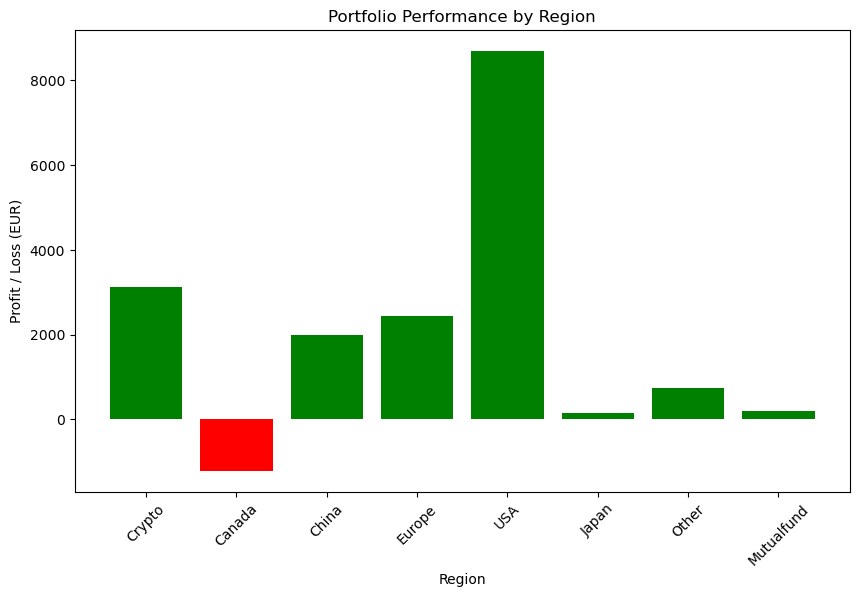

Initial investment:   51191 EUR
Overall gain so far:  16137 EUR /  31.52  % (w/o dividends)
Current investment:   67327 EUR (w/o dividends)


In [ ]:
df_my_portfolio = get_my_portfolio(b[0])

# Create a dictionary from ETF data for easy lookup
etf_data = {etf['ticker']: etf['countries'] for etf in c}

# Prepare the transformed portfolio data
b2 = [{'symbol': b[0][i], 'num_equities': b[1][i], 'purchase_price': b[2][i]} for i in range(len(b[0]))]

# Call function to plot the portfolio
region_labels, region_values = plot_portfolio(df_my_portfolio, b2, etf_data)
print("Initial investment:  ",round(inital_mon), "EUR")
print("Overall gain so far: ",round(sum(region_values)), "EUR /",round(100*sum(region_values)/inital_mon,2),"% (w/o dividends)")
print("Current investment:  ",round(sum(region_values)+inital_mon), "EUR           (w/o dividends)")

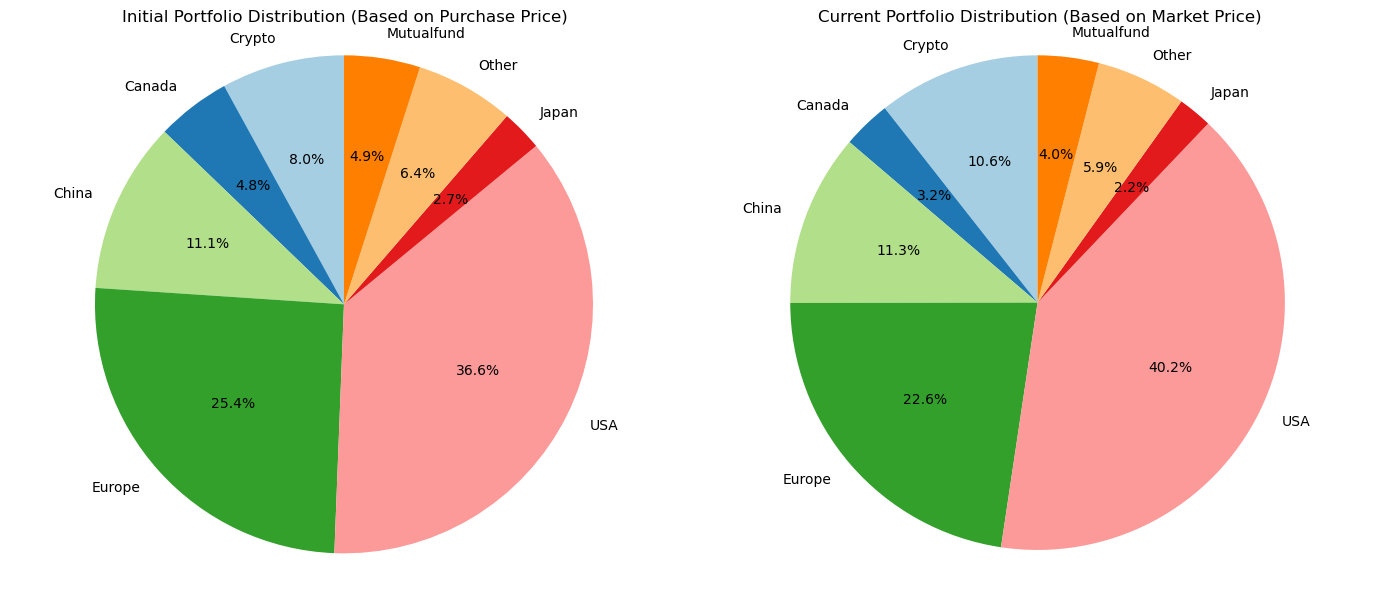

In [ ]:
#import matplotlib.pyplot as plt
#from collections import defaultdict

plot_country_distribution(df_my_portfolio, b2, etf_data)

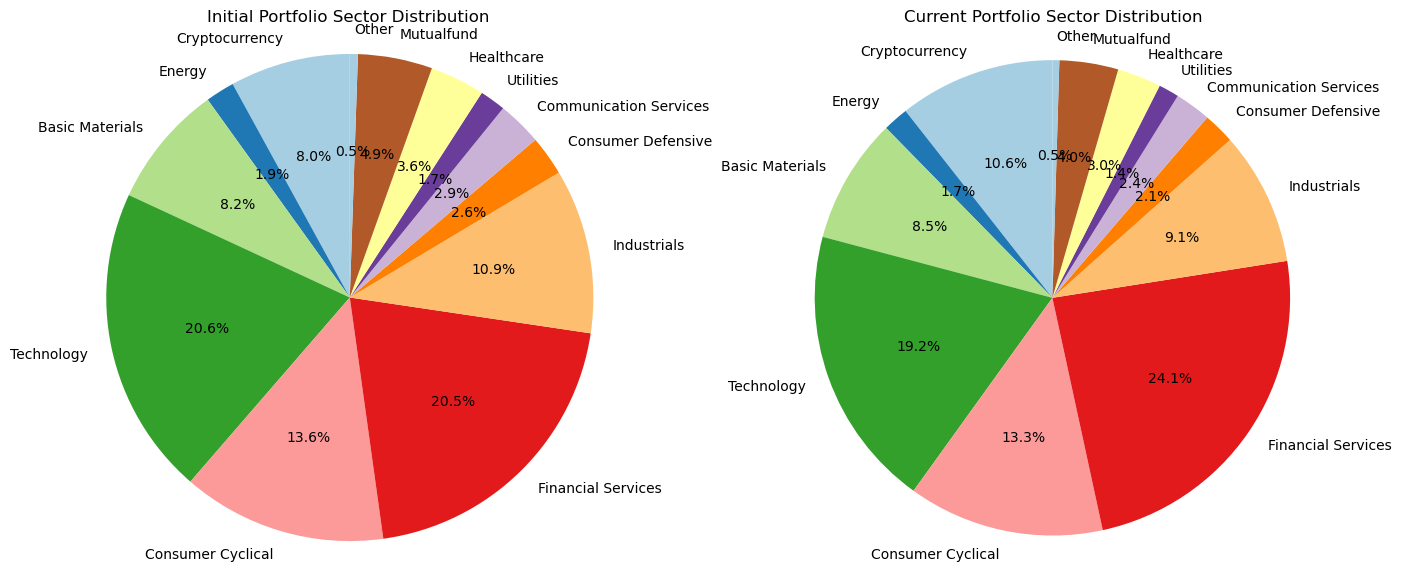

In [15]:
#Idea here is to create a pie chart again, but not with countries, but sectors 
# import yfinance as yf
# import matplotlib.pyplot as plt
# from collections import defaultdict

get_sector_distribution(df_my_portfolio, b2)

In [116]:
# Next ideas: 
# 1    Include dividends into calcualtions 
# 2    Intrinsic value of a copmany. YIelding in when to sell, etc

In [117]:
# Dividends 

# For Aktien: yf.Ticker('BY6.F').info['dividendYield']
# For ETFs:   Addind together all dividends from last year and comparing to current purachse price. Note: Stock price at the dividend date NOT considered

yield_percentages, yield_EUR = calculate_dividends(df_my_portfolio, b2, etf_data)

print(round(sum(np.array(yield_EUR)*np.array(b[1]))), "EUR")

644 EUR


In [ ]:
df_my_portfolio[11]['sector'] #Aktien: 'sector': technology, 'dividendYield' : 0.84 %,  'trailingEps': 1.07, 'forwardEps': 1.93,
# ETF: yf.Ticker(xy).funds_data.sector_weightings, written dividend funtion, 
yf.Ticker("BY6.F").info['currentPrice']/yf.Ticker("BY6.F").info['trailingEps']
yf.Ticker("BYDDY").info['currentPrice']/yf.Ticker("BYDDY").info['forwardEps']